Food Delivery Time Predictor

In [2]:
# import the libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [3]:
# Dataset
data = {
    'distance_km': [2.5, 6.0, 1.2, 8.5, 3.8, 5.2, 1.8, 7.0, 4.5, 9.2,
                    2.0, 6.5, 3.2, 7.8, 4.0, 5.8, 1.5, 8.0, 3.5, 6.8,
                    2.2, 5.5, 4.2, 9.0, 2.8, 7.2, 3.0, 6.2, 4.8, 8.2],

    'prep_time_min': [10, 20, 8, 25, 12, 18, 7, 22, 15, 28,
                      9, 19, 11, 24, 14, 17, 6, 26, 13, 21,
                      10, 16, 14, 27, 11, 23, 12, 18, 15, 25],

    'delivery_time_min': [18, 38, 12, 52, 24, 34, 14, 45, 29, 58,
                          15, 40, 21, 50, 27, 35, 11, 54, 23, 43,
                          17, 32, 26, 56, 19, 47, 20, 37, 30, 53]
}

In [4]:
df = pd.DataFrame(data)

In [5]:
df.head()

,distance_km,prep_time_min,delivery_time_min
0,2.5,10,18
1,6.0,20,38
2,1.2,8,12
3,8.5,25,52
4,3.8,12,24


In [6]:
df.describe()

,distance_km,prep_time_min,delivery_time_min
count,30.000000,30.000000,30.000000
mean,5.063333,16.533333,32.666667
std,2.408818,6.415140,14.465973
min,1.200000,6.000000,11.000000
25%,3.050000,11.250000,20.250000
50%,5.000000,15.500000,31.000000
75%,6.950000,21.750000,44.500000
max,9.200000,28.000000,58.000000


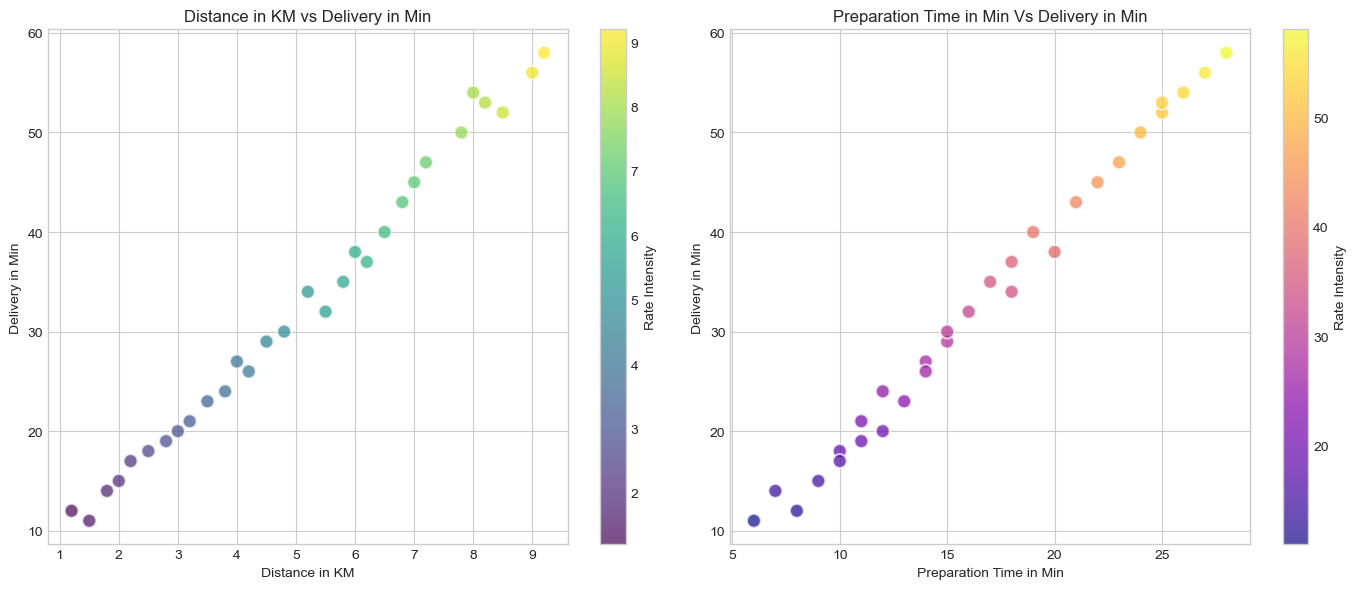

In [10]:
# Visualize the data
plt.style.use('seaborn-v0_8-whitegrid')
fig, axis = plt.subplots(1,2, figsize=(14,6))
scatter1 = axis[0].scatter(df['distance_km'], df['delivery_time_min'],
                           c =df['distance_km'], cmap='viridis', s=100, alpha=0.7, edgecolors='white', linewidth=1.5)
axis[0].set_xlabel('Distance in KM')
axis[0].set_ylabel('Delivery in Min')
axis[0].set_title('Distance in KM vs Delivery in Min')
plt.colorbar(scatter1, ax=axis[0], label='Rate Intensity')

scatter2 = axis[1].scatter(df['prep_time_min'], df['delivery_time_min'],
                           c = df['delivery_time_min'], cmap='plasma', s=100, alpha =0.7, edgecolors='white',linewidth=1.5)
axis[1].set_xlabel('Preparation Time in Min')
axis[1].set_ylabel('Delivery in Min')
axis[1].set_title('Preparation Time in Min Vs Delivery in Min')
plt.colorbar(scatter2, ax=axis[1], label='Rate Intensity')

plt.tight_layout()
plt.show()

In [13]:
# prepare data for training
X = df[['distance_km','prep_time_min']]
y = df['delivery_time_min']

In [15]:
# split the data into training and testing data set
random_state =42
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =0.2)

In [16]:
# create model and train the model
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
# check model parameters
distance_coeff = model.coef_[0].round()
prep_time_coeff = model.coef_[1].round()
intercept = model.intercept_

In [23]:
distance_coeff, prep_time_coeff, intercept
# distance_coeff factor effects delivery time more 

(np.float64(3.0), np.float64(1.0), np.float64(-0.973524591908415))

In [18]:
y_pred = model.predict(X_test)

In [19]:
y_pred

array([19.51880307, 51.91680678, 11.23419244, 20.80809586, 52.48594292,
       17.50935365])

In [21]:
results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred.round()})
results

,Actual,Predicted
0,19,20.0
1,54,52.0
2,12,11.0
3,21,21.0
4,52,52.0
5,18,18.0


In [25]:
score = r2_score(y_pred, y_test)
score

0.996604571988656

In [27]:
new_delivery = [[7,15]]
pred_time = model.predict(new_delivery)
pred_time

C:\Users\G.Guna\desktop\ML\heart_disease_project\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([37.22629664])

In [31]:
print(f"\nQuestion: 7km distance, 15 minutes preparation time")
print(f"Predicted Delivery Time: {pred_time[0]:,.0f} min")


Question: 7km distance, 15 minutes preparation time
Predicted Delivery Time: 37 min
